# Analysis 

## P1 - Load,Clean & Merge

In [6]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [7]:
Tickets = pd.read_csv("Tickets.csv")
Teams = pd.read_csv("Teams.csv")    

In [8]:
Data1 = pd.DataFrame(Tickets)
Data2 = pd.DataFrame(Teams)

In [9]:
Data1

,ticket_id,month,team_id,channel,resolution_hours,satisfaction
0,1,Jan,T1,Email,12,4
1,2,Jan,T2,Chat,28,3
2,3,Jan,T3,Phone,36,2
3,4,Jan,T4,Email,20,4
4,5,Feb,T1,Chat,8,5
5,6,Feb,T2,Phone,30,3
6,7,Feb,T3,Email,18,4
7,8,Feb,T4,Chat,40,2
8,9,Mar,T1,Phone,16,4
9,10,Mar,T2,Email,22,4


In [10]:
Data2

,team_id,team,department
0,T1,AccountCare,Service
1,T2,BillingHelp,Service
2,T3,AppSupport,Technical
3,T4,DeviceHelp,Technical


### Understand Data

In [11]:
Data1.info()

<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   ticket_id         13 non-null     int64
 1   month             13 non-null     str  
 2   team_id           13 non-null     str  
 3   channel           13 non-null     str  
 4   resolution_hours  13 non-null     int64
 5   satisfaction      13 non-null     int64
dtypes: int64(3), str(3)
memory usage: 756.0 bytes


In [12]:
Data2.info()

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   team_id     4 non-null      str  
 1   team        4 non-null      str  
 2   department  4 non-null      str  
dtypes: str(3)
memory usage: 228.0 bytes


In [13]:
print("Data1 shape:", Data1.shape)
print("Data2 shape:", Data2.shape)

Data1 shape: (13, 6)
Data2 shape: (4, 3)


### Check & Drop duplicates

In [14]:
Data1[Data1.duplicated()]

,ticket_id,month,team_id,channel,resolution_hours,satisfaction
12,12,Mar,T4,Phone,24,5


In [15]:
Data1_Cleaned = Data1.drop_duplicates().copy()

In [16]:
Data1_Cleaned[Data1_Cleaned.duplicated()]

,ticket_id,month,team_id,channel,resolution_hours,satisfaction


In [17]:
print("No duplicates in the dataset.")

No duplicates in the dataset.


In [18]:
print("Data1_Cleaned shape:", Data1_Cleaned.shape)
print("Data2 shape:", Data2.shape)

Data1_Cleaned shape: (12, 6)
Data2 shape: (4, 3)


### Merge 

In [19]:
Merged = Data1_Cleaned.merge(Data2, how='left',on='team_id',validate='many_to_one')

In [20]:
Merged

,ticket_id,month,team_id,channel,resolution_hours,satisfaction,team,department
0,1,Jan,T1,Email,12,4,AccountCare,Service
1,2,Jan,T2,Chat,28,3,BillingHelp,Service
2,3,Jan,T3,Phone,36,2,AppSupport,Technical
3,4,Jan,T4,Email,20,4,DeviceHelp,Technical
4,5,Feb,T1,Chat,8,5,AccountCare,Service
5,6,Feb,T2,Phone,30,3,BillingHelp,Service
6,7,Feb,T3,Email,18,4,AppSupport,Technical
7,8,Feb,T4,Chat,40,2,DeviceHelp,Technical
8,9,Mar,T1,Phone,16,4,AccountCare,Service
9,10,Mar,T2,Email,22,4,BillingHelp,Service


### Assertion check

In [21]:
assert len(Merged) == 12
assert Merged['team_id'].isnull().sum() == 0

## P2 - Derived field & Department

### Revenue column

In [22]:
breach_flag = (Merged['resolution_hours'] > 24).astype(int)

In [23]:
Merged['breach_flag'] = breach_flag

In [24]:
Merged

,ticket_id,month,team_id,channel,resolution_hours,satisfaction,team,department,breach_flag
0,1,Jan,T1,Email,12,4,AccountCare,Service,0
1,2,Jan,T2,Chat,28,3,BillingHelp,Service,1
2,3,Jan,T3,Phone,36,2,AppSupport,Technical,1
3,4,Jan,T4,Email,20,4,DeviceHelp,Technical,0
4,5,Feb,T1,Chat,8,5,AccountCare,Service,0
5,6,Feb,T2,Phone,30,3,BillingHelp,Service,1
6,7,Feb,T3,Email,18,4,AppSupport,Technical,0
7,8,Feb,T4,Chat,40,2,DeviceHelp,Technical,1
8,9,Mar,T1,Phone,16,4,AccountCare,Service,0
9,10,Mar,T2,Email,22,4,BillingHelp,Service,0


### Summary

In [25]:
Total_Tickets = len(Merged['satisfaction'])
Total_Tickets

12

In [26]:
Sum_Breach = Merged['breach_flag'].sum()
print(Sum_Breach)

5


In [29]:
Merged.to_csv("Clean_Data.csv", index=False)

## P3 - Chart & Exports

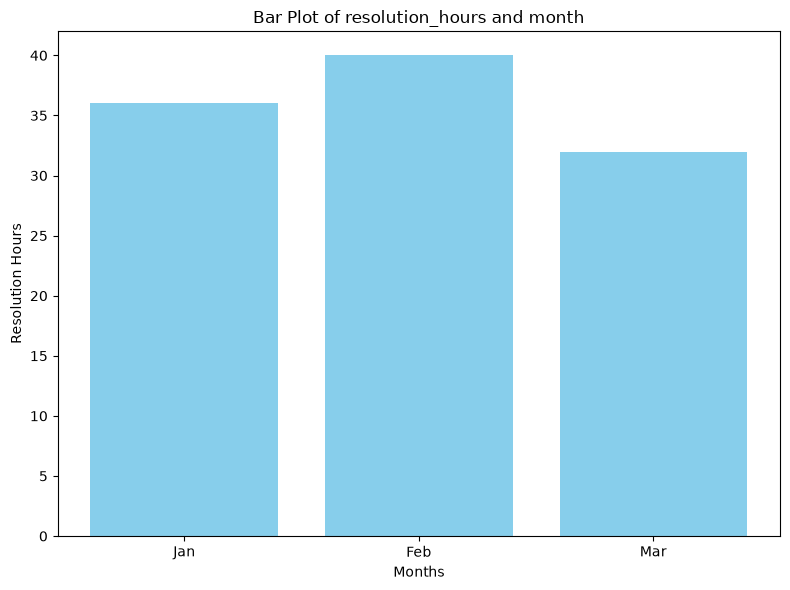

In [ ]:
plt.figure(figsize=(8, 6))
plt.bar(Merged['month'], Merged['resolution_hours'], color='skyblue')
plt.title('Bar Plot of resolution_hours and month')
plt.xlabel('Months')
plt.ylabel('Resolution Hours')
plt.tight_layout()
plt.savefig('bar_plot.png')  
plt.show()